In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,roc_auc_score,precision_score,recall_score,classification_report,f1_score
from collections import Counter 
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier,NearestNeighbors
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import confusion_matrix
import pyttsx3
import pickle
from matplotlib import pyplot as plt
import matplotlib.image as mpimg
plt.style.use("dark_background")



In [2]:
data=pd.read_csv("nasa.csv")
data

,neo_id,name,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
0,2162117,162117 (1998 SD15),19.140,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
1,2349507,349507 (2008 QY),18.500,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
2,2455415,455415 (2003 GA),21.450,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
3,3132126,(2002 PB),20.630,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
4,3557844,(2011 DW),22.700,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False
...,...,...,...,...,...,...,...,...,...
338194,54403809,(2023 VS4),28.580,0.005112,0.011430,Earth,56646.985988,6.406548e+07,False
338195,54415298,(2023 XW5),28.690,0.004859,0.010865,Earth,21130.768947,2.948883e+07,False
338196,54454871,(2024 KJ7),21.919,0.109839,0.245607,Earth,11832.041031,5.346078e+07,False
338197,54456245,(2024 NE),23.887,0.044377,0.099229,Earth,56198.382733,5.184742e+06,False


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338199 entries, 0 to 338198
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   neo_id                  338199 non-null  int64  
 1   name                    338199 non-null  object 
 2   absolute_magnitude      338171 non-null  float64
 3   estimated_diameter_min  338171 non-null  float64
 4   estimated_diameter_max  338171 non-null  float64
 5   orbiting_body           338199 non-null  object 
 6   relative_velocity       338199 non-null  float64
 7   miss_distance           338199 non-null  float64
 8   is_hazardous            338199 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 21.0+ MB


In [4]:
data.isna().sum()

neo_id                     0
name                       0
absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
orbiting_body              0
relative_velocity          0
miss_distance              0
is_hazardous               0
dtype: int64

In [5]:
data.describe()

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
count,3.381990e+05,338171.000000,338171.000000,338171.000000,338199.000000,3.381990e+05
mean,1.759939e+07,22.932525,0.157812,0.352878,51060.662908,4.153535e+07
std,2.287225e+07,2.911216,0.313885,0.701869,26399.238435,2.077399e+07
min,2.000433e+06,9.250000,0.000511,0.001143,203.346433,6.745533e+03
25%,3.373980e+06,20.740000,0.025384,0.056760,30712.031471,2.494540e+07
50%,3.742127e+06,22.800000,0.073207,0.163697,47560.465474,4.332674e+07
75%,5.405374e+07,25.100000,0.189041,0.422708,66673.820614,5.933961e+07
max,5.446281e+07,33.580000,37.545248,83.953727,291781.106613,7.479865e+07


<Axes: >

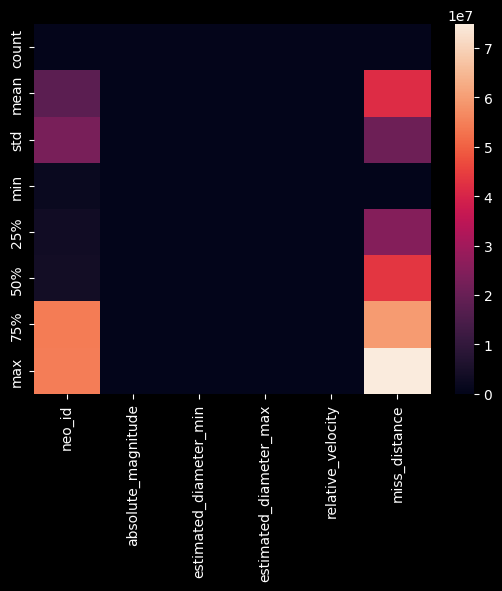

In [6]:
sns.heatmap(data.describe())

In [7]:
NEO_NAME=pd.DataFrame(data["name"])
NEO_NAME

,name
0,162117 (1998 SD15)
1,349507 (2008 QY)
2,455415 (2003 GA)
3,(2002 PB)
4,(2011 DW)
...,...
338194,(2023 VS4)
338195,(2023 XW5)
338196,(2024 KJ7)
338197,(2024 NE)


In [8]:
data=data.set_index('name').rename_axis(None)
data

,neo_id,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,orbiting_body,relative_velocity,miss_distance,is_hazardous
162117 (1998 SD15),2162117,19.140,0.394962,0.883161,Earth,71745.401048,5.814362e+07,False
349507 (2008 QY),2349507,18.500,0.530341,1.185878,Earth,109949.757148,5.580105e+07,True
455415 (2003 GA),2455415,21.450,0.136319,0.304818,Earth,24865.506798,6.720689e+07,False
(2002 PB),3132126,20.630,0.198863,0.444672,Earth,78890.076805,3.039644e+07,False
(2011 DW),3557844,22.700,0.076658,0.171412,Earth,56036.519484,6.311863e+07,False
...,...,...,...,...,...,...,...,...
(2023 VS4),54403809,28.580,0.005112,0.011430,Earth,56646.985988,6.406548e+07,False
(2023 XW5),54415298,28.690,0.004859,0.010865,Earth,21130.768947,2.948883e+07,False
(2024 KJ7),54454871,21.919,0.109839,0.245607,Earth,11832.041031,5.346078e+07,False
(2024 NE),54456245,23.887,0.044377,0.099229,Earth,56198.382733,5.184742e+06,False


In [9]:
NEO_ID=pd.DataFrame(data['neo_id'])
NEO_ID

,neo_id
162117 (1998 SD15),2162117
349507 (2008 QY),2349507
455415 (2003 GA),2455415
(2002 PB),3132126
(2011 DW),3557844
...,...
(2023 VS4),54403809
(2023 XW5),54415298
(2024 KJ7),54454871
(2024 NE),54456245


In [10]:
data=data.drop(['neo_id',"orbiting_body"],axis=1)
data


,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,is_hazardous
162117 (1998 SD15),19.140,0.394962,0.883161,71745.401048,5.814362e+07,False
349507 (2008 QY),18.500,0.530341,1.185878,109949.757148,5.580105e+07,True
455415 (2003 GA),21.450,0.136319,0.304818,24865.506798,6.720689e+07,False
(2002 PB),20.630,0.198863,0.444672,78890.076805,3.039644e+07,False
(2011 DW),22.700,0.076658,0.171412,56036.519484,6.311863e+07,False
...,...,...,...,...,...,...
(2023 VS4),28.580,0.005112,0.011430,56646.985988,6.406548e+07,False
(2023 XW5),28.690,0.004859,0.010865,21130.768947,2.948883e+07,False
(2024 KJ7),21.919,0.109839,0.245607,11832.041031,5.346078e+07,False
(2024 NE),23.887,0.044377,0.099229,56198.382733,5.184742e+06,False


In [11]:
data.corr()

,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance,is_hazardous
absolute_magnitude,1.000000,-0.594646,-0.594646,-0.345570,-0.213523,-0.343996
estimated_diameter_min,-0.594646,1.000000,1.000000,0.222434,0.111475,0.164841
estimated_diameter_max,-0.594646,1.000000,1.000000,0.222434,0.111475,0.164841
relative_velocity,-0.345570,0.222434,0.222434,1.000000,0.322587,0.187021
miss_distance,-0.213523,0.111475,0.111475,0.322587,1.000000,-0.006540
is_hazardous,-0.343996,0.164841,0.164841,0.187021,-0.006540,1.000000


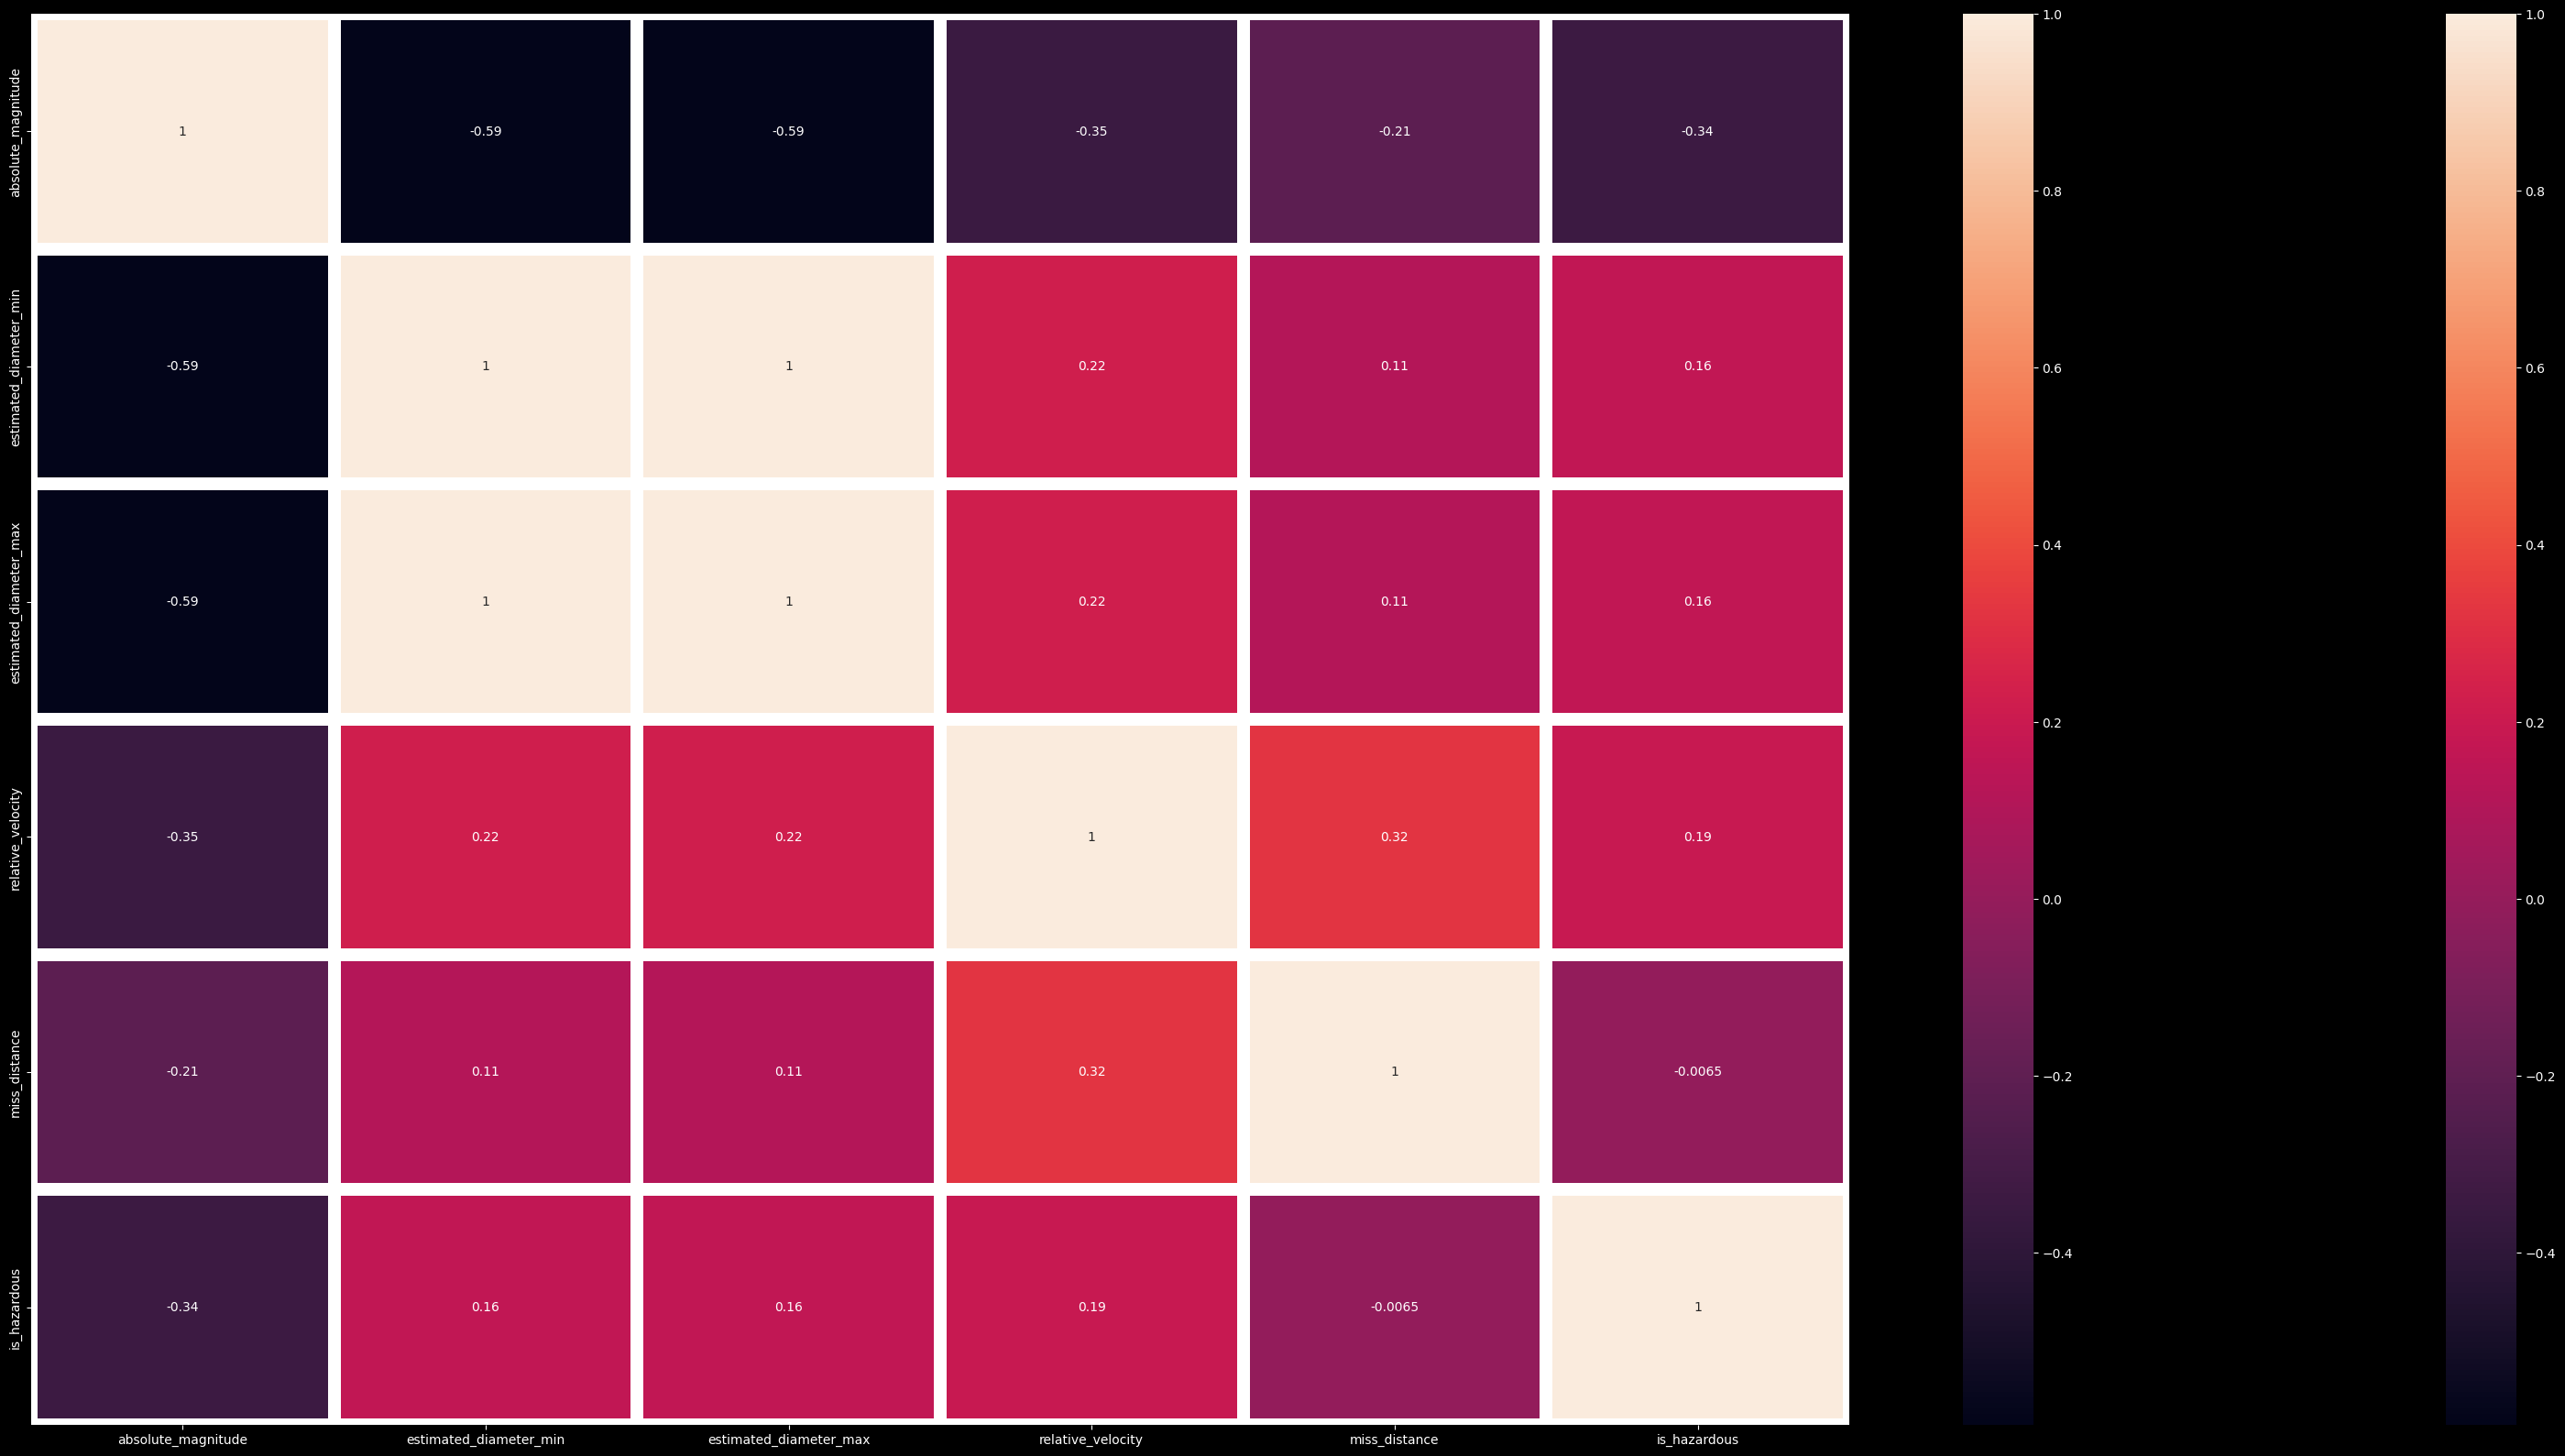

In [12]:
plt.figure(figsize=(40,20))
sns.heatmap(data.corr())
top_corr_features=data.corr().index
g=sns.heatmap(data[top_corr_features].corr(),annot=True,linewidth=10,cmap="rocket")

<Axes: >

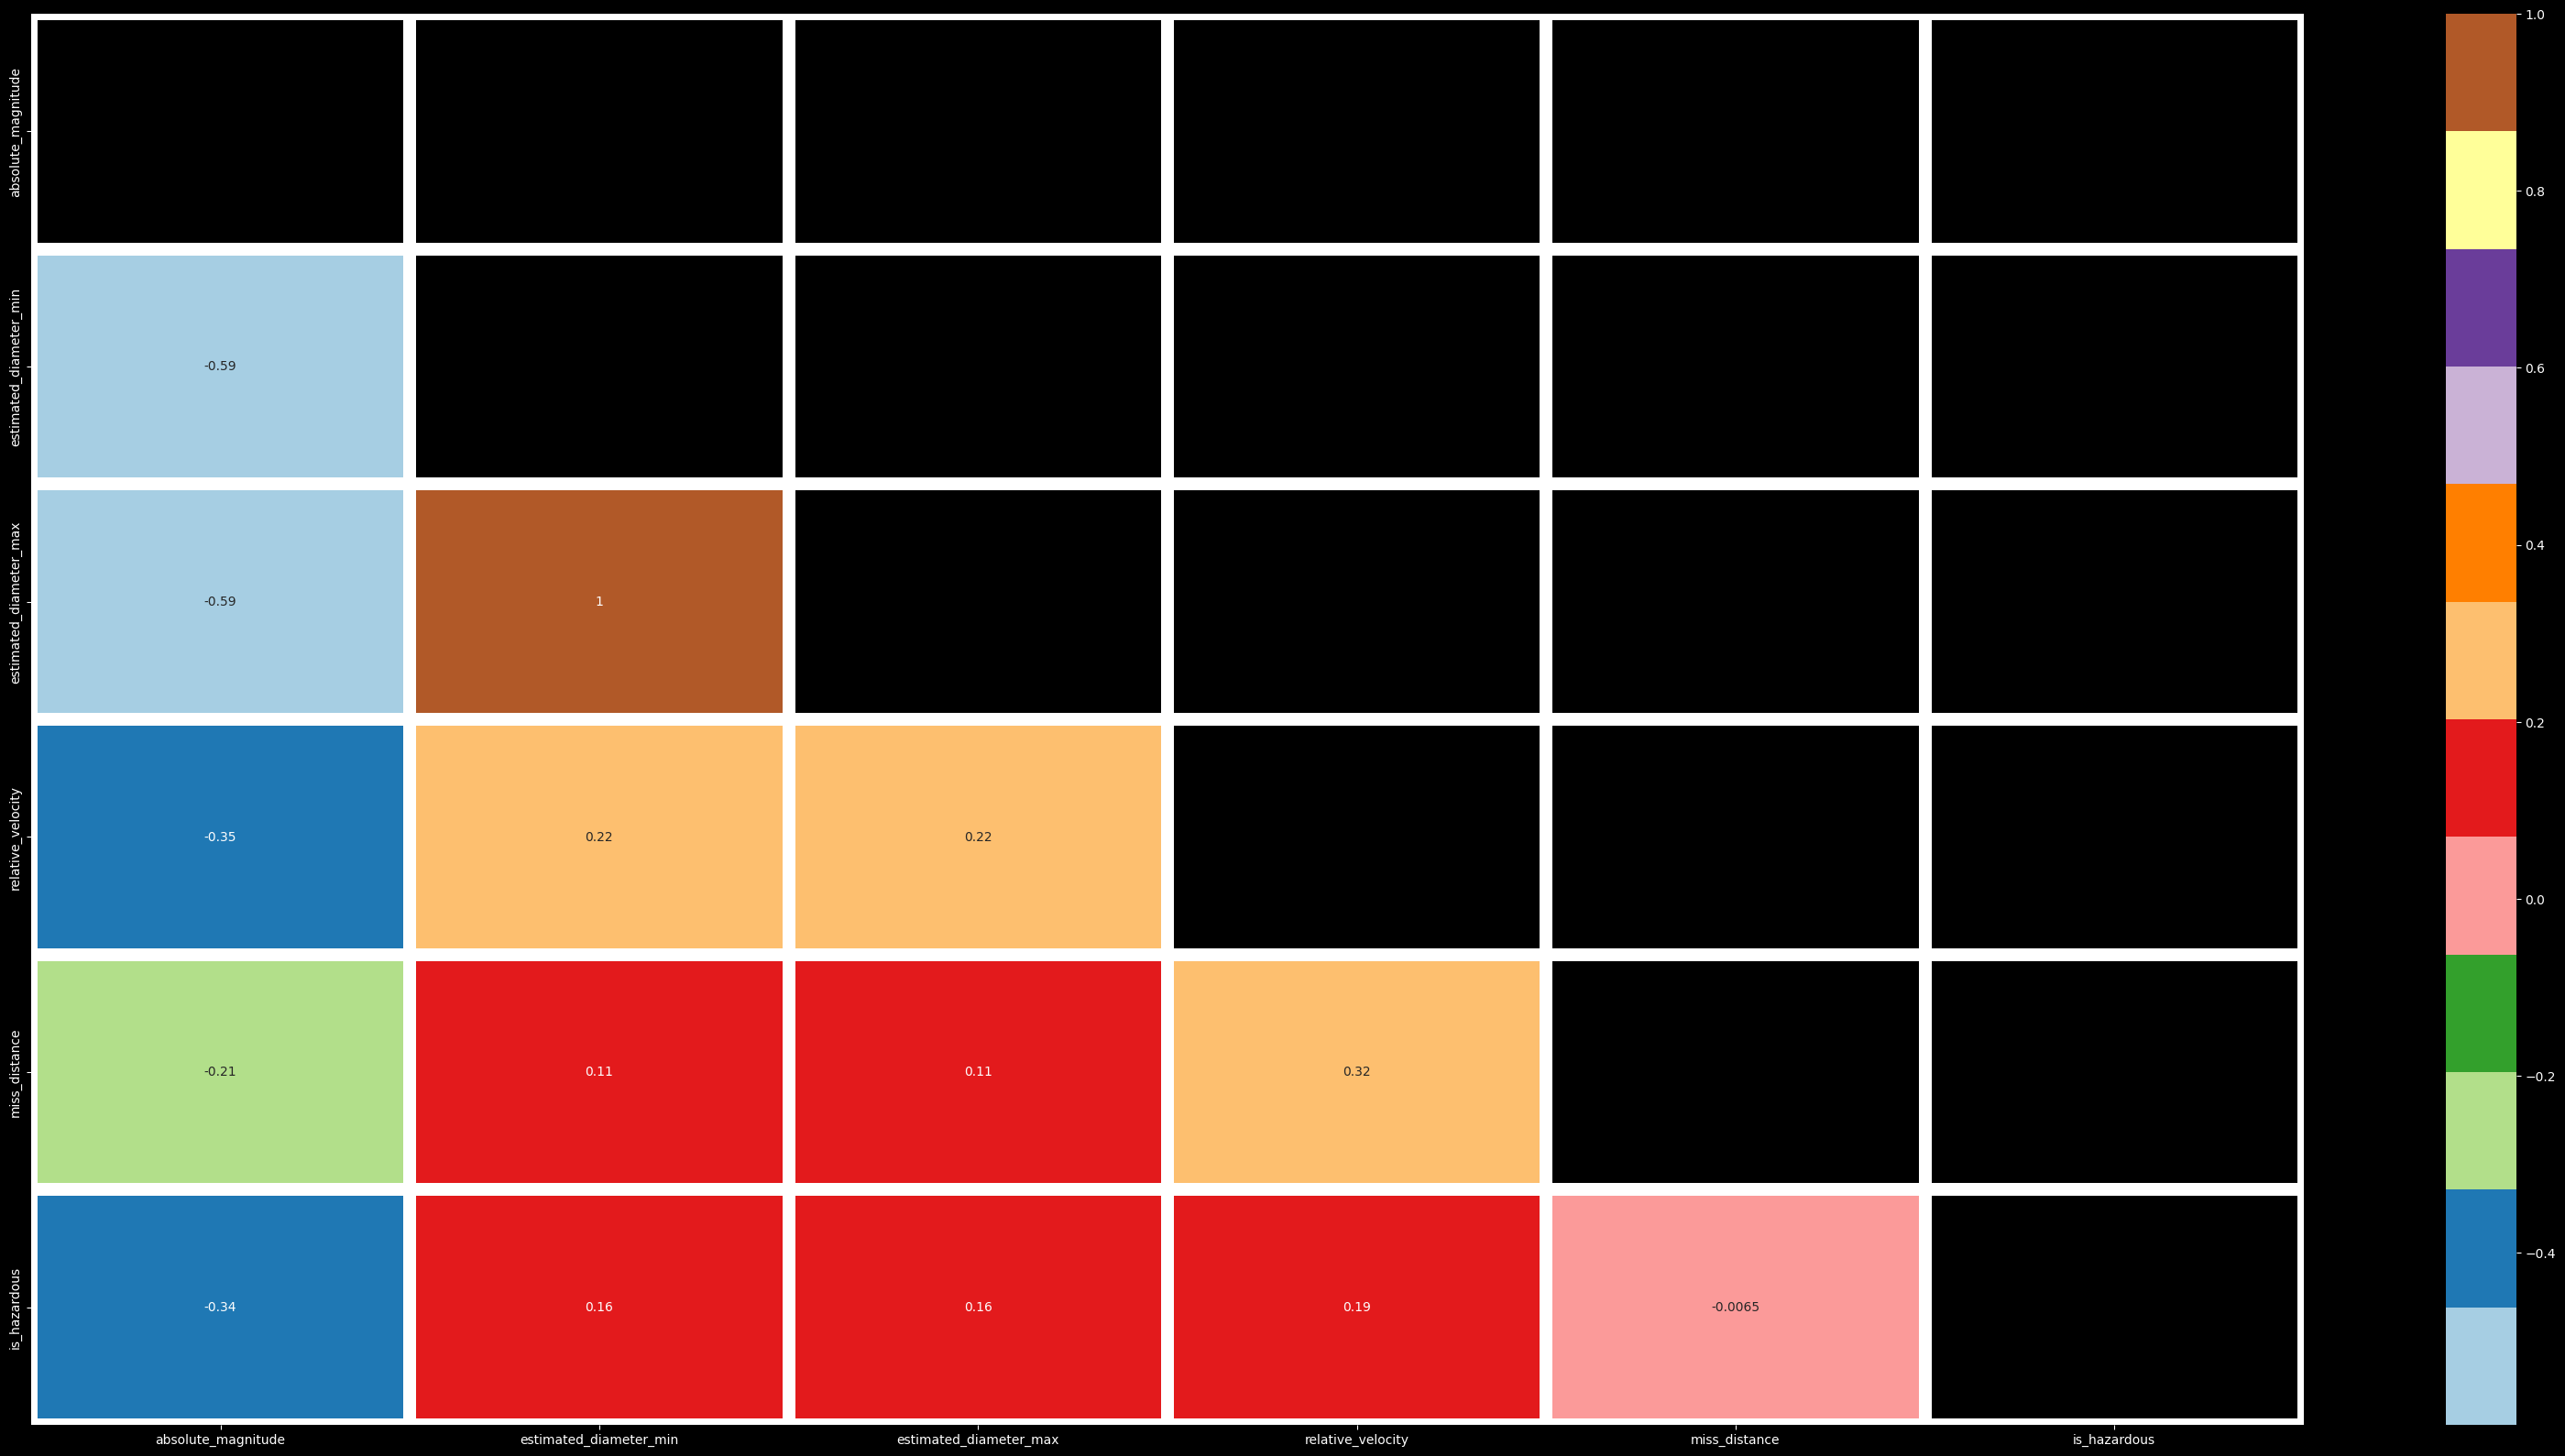

In [13]:
plt.figure(figsize=(40,20))
matrix=np.triu(data.corr())
sns.heatmap(data.corr(),annot=True,linewidth=10,mask=matrix,cmap="Paired")

<Axes: ylabel='Count'>

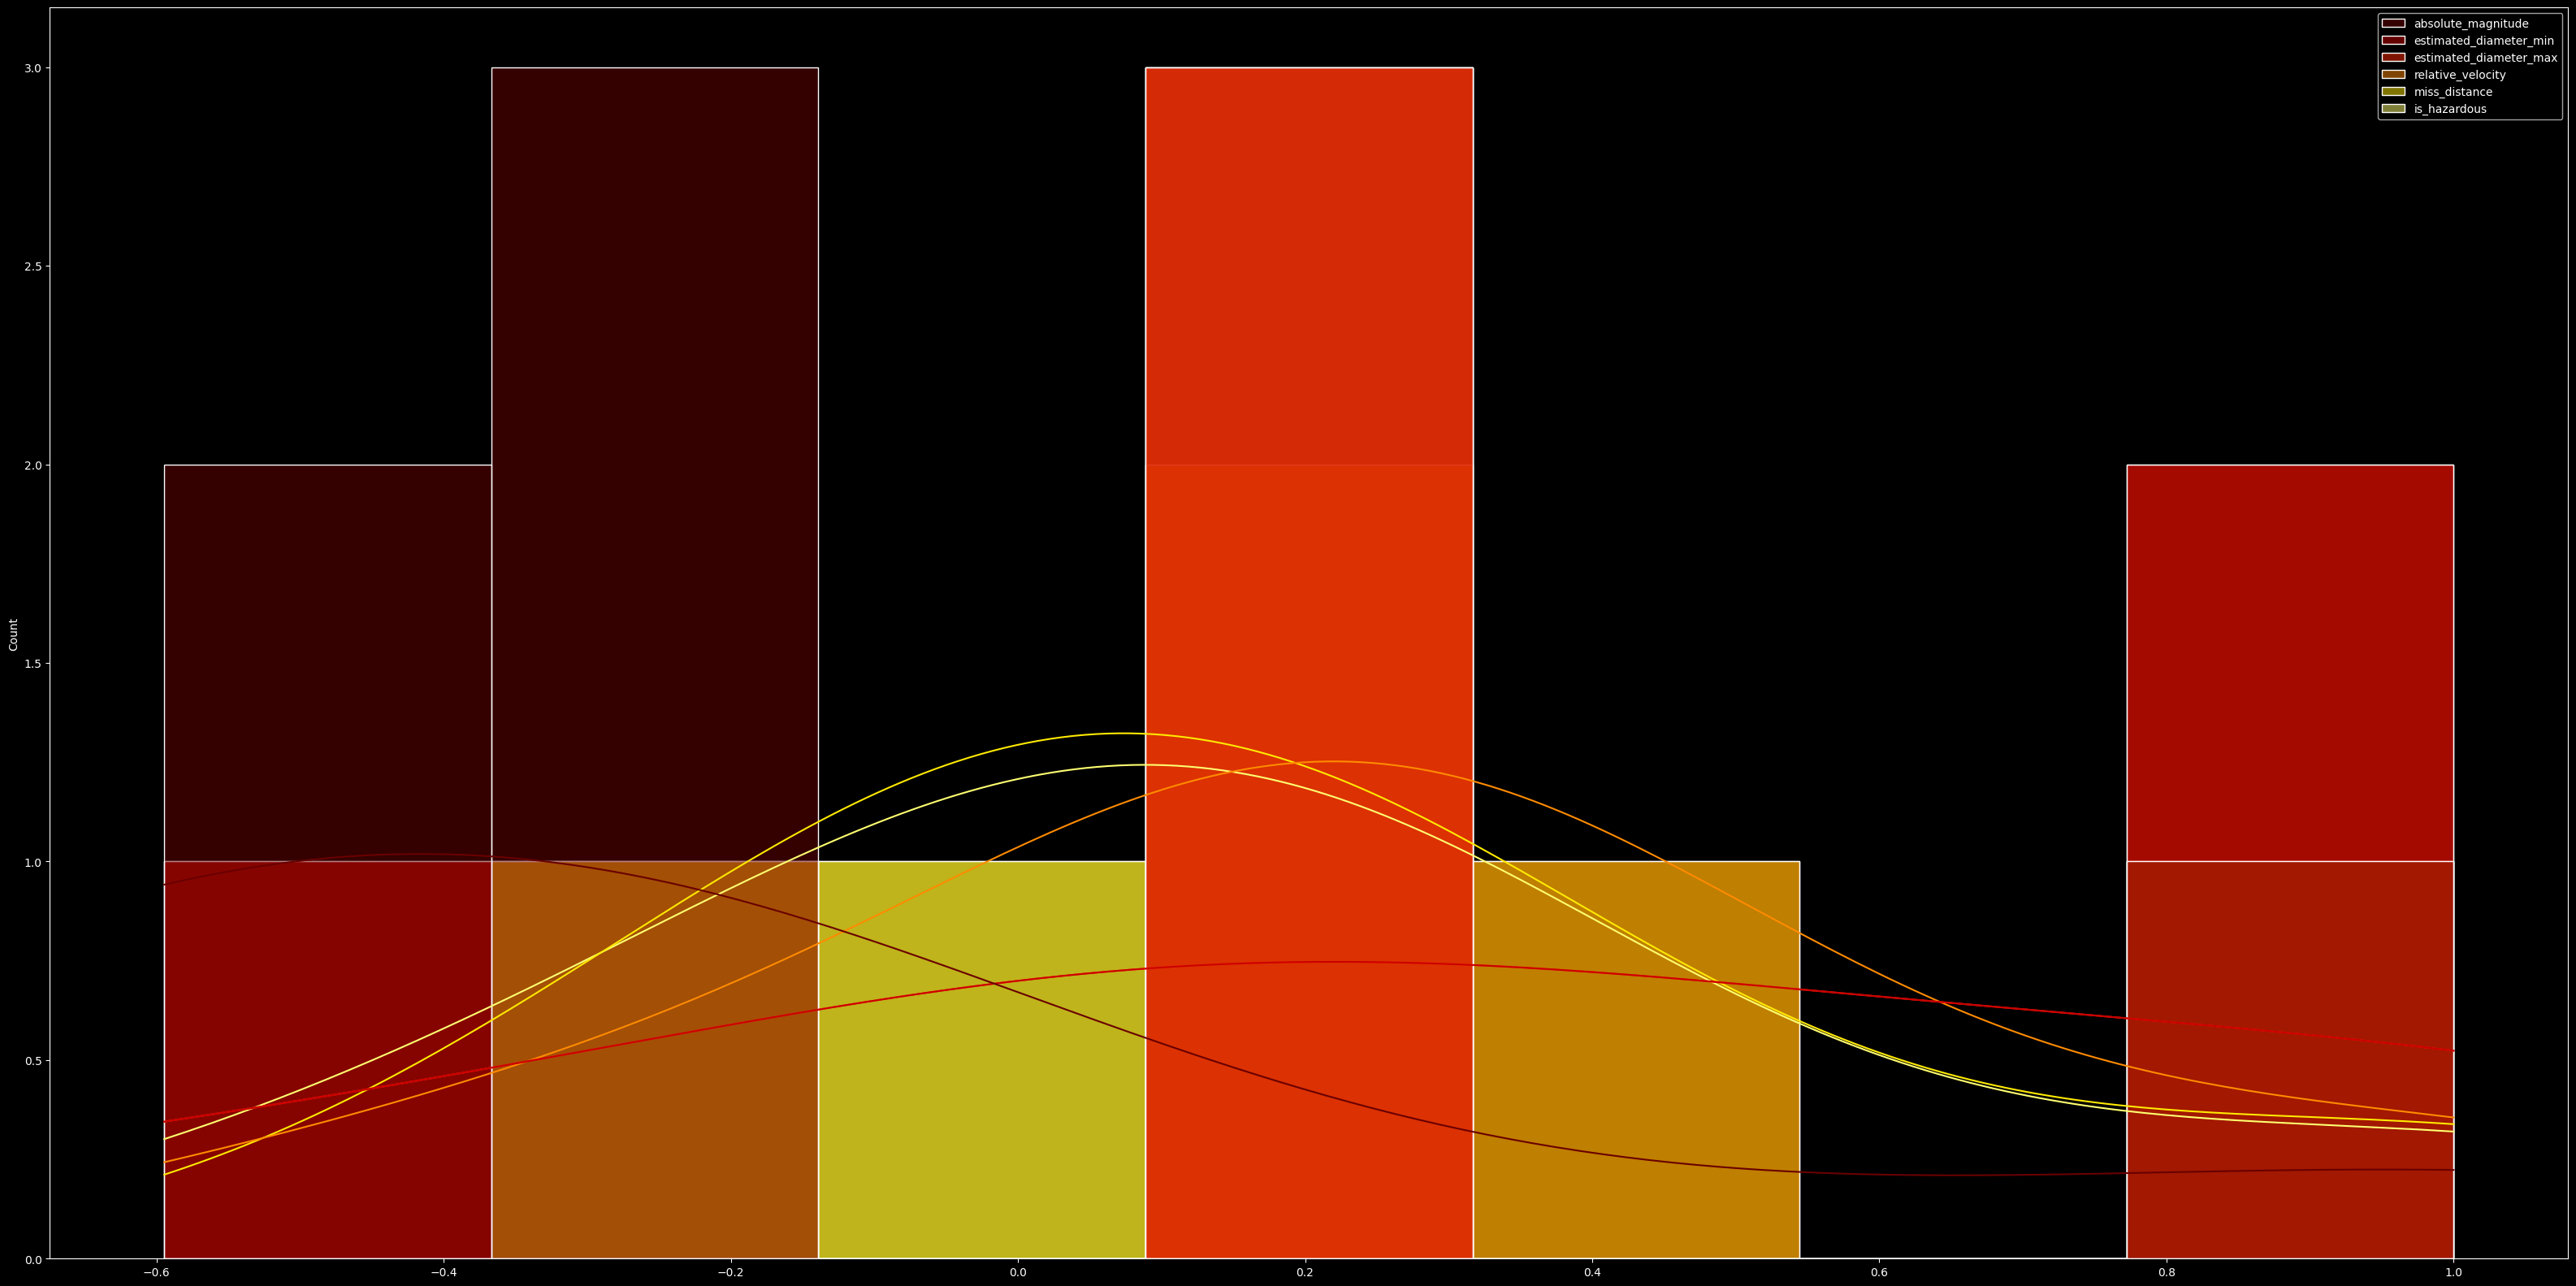

In [14]:
plt.figure(figsize=(40,20))
sns.histplot(data=data.corr(),kde=True,palette='hot')

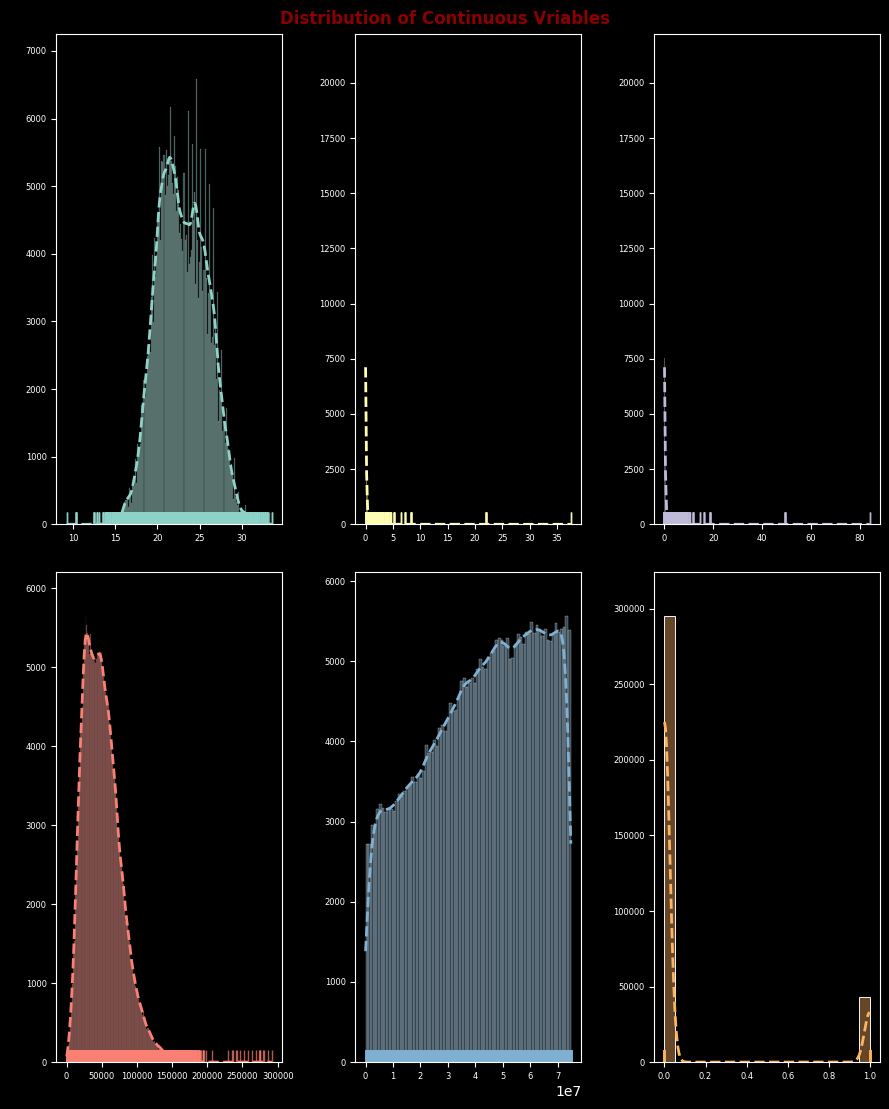

In [15]:
fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(9,12))
axes=axes.flat

color_cycle=list((plt.rcParams['axes.prop_cycle']))
num_colors=len(color_cycle)

for i,num_col in enumerate(data.columns):
    sns.histplot(data[num_col],stat='count',kde=True,color=color_cycle[i%num_colors]["color"],line_kws={'linewidth':2,'linestyle':'dashed'},alpha=0.4,ax=axes[i])
    sns.rugplot(data[num_col],color=color_cycle[i%num_colors]["color"],ax=axes[i],alpha=0.7)

    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count",fontsize=7,fontweight='bold',color='black')
    axes[i].set_title(num_col,fontsize=8,fontweight='bold',color='black')
    axes[i].tick_params(labelsize=6)

fig.suptitle('Distribution of Continuous Vriables',fontsize=12,fontweight='bold',color='darkred',y=0.92)
fig.tight_layout()
fig.subplots_adjust(top=0.9)

plt.show()

In [16]:
data.nunique()

absolute_magnitude          1778
estimated_diameter_min      1778
estimated_diameter_max      1778
relative_velocity         338189
miss_distance             337826
is_hazardous                   2
dtype: int64

In [17]:
'''LE=LabelEncoder() data['is_hazardous]=LE.fit_transform(data['is_hazardous]) data'''

"LE=LabelEncoder() data['is_hazardous]=LE.fit_transform(data['is_hazardous]) data"

In [18]:
is_hazardous=[]
for i in data['is_hazardous']:
    if i==False:
        is_hazardous.append(0)
    elif i==True:
        is_hazardous.append(1)
print(is_hazardous)

[0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 

In [19]:
is_hazardous=pd.DataFrame(is_hazardous)
is_hazardous.rename(columns={0:'is_hazardous'},inplace=True)
is_hazardous=is_hazardous.set_index(NEO_NAME['name'].values).rename_axis(None)
is_hazardous

,is_hazardous
162117 (1998 SD15),0
349507 (2008 QY),1
455415 (2003 GA),0
(2002 PB),0
(2011 DW),0
...,...
(2023 VS4),0
(2023 XW5),0
(2024 KJ7),0
(2024 NE),0


In [20]:
x=data.drop('is_hazardous',axis=1)
x

,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
162117 (1998 SD15),19.140,0.394962,0.883161,71745.401048,5.814362e+07
349507 (2008 QY),18.500,0.530341,1.185878,109949.757148,5.580105e+07
455415 (2003 GA),21.450,0.136319,0.304818,24865.506798,6.720689e+07
(2002 PB),20.630,0.198863,0.444672,78890.076805,3.039644e+07
(2011 DW),22.700,0.076658,0.171412,56036.519484,6.311863e+07
...,...,...,...,...,...
(2023 VS4),28.580,0.005112,0.011430,56646.985988,6.406548e+07
(2023 XW5),28.690,0.004859,0.010865,21130.768947,2.948883e+07
(2024 KJ7),21.919,0.109839,0.245607,11832.041031,5.346078e+07
(2024 NE),23.887,0.044377,0.099229,56198.382733,5.184742e+06


In [21]:
x.isna().sum()

absolute_magnitude        28
estimated_diameter_min    28
estimated_diameter_max    28
relative_velocity          0
miss_distance              0
dtype: int64

In [22]:
x=np.array(x)
x

array([[1.91400000e+01, 3.94961694e-01, 8.83161196e-01, 7.17454010e+04,
        5.81436233e+07],
       [1.85000000e+01, 5.30340723e-01, 1.18587791e+00, 1.09949757e+05,
        5.58010478e+07],
       [2.14500000e+01, 1.36318556e-01, 3.04817558e-01, 2.48655068e+04,
        6.72068877e+07],
       ...,
       [2.19190000e+01, 1.09838597e-01, 2.45606569e-01, 1.18320410e+04,
        5.34607845e+07],
       [2.38870000e+01, 4.43766973e-02, 9.92293117e-02, 5.61983827e+04,
        5.18474239e+06],
       [2.29510000e+01, 6.82896641e-02, 1.52700331e-01, 4.20603578e+04,
        7.12668246e+06]], shape=(338199, 5))

In [23]:
imp_mean=SimpleImputer(missing_values=np.nan,strategy='mean')
x[:,0:3]=imp_mean.fit_transform(x[:,0:3])

In [24]:
x=pd.DataFrame(x,columns=['absolute_magnitude','estimated_diameter_min','estimated_diameter_max','relative_velocity','miss_distance'])
x=x.set_index(NEO_NAME['name'].values).rename_axis(None)
x

,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
162117 (1998 SD15),19.140,0.394962,0.883161,71745.401048,5.814362e+07
349507 (2008 QY),18.500,0.530341,1.185878,109949.757148,5.580105e+07
455415 (2003 GA),21.450,0.136319,0.304818,24865.506798,6.720689e+07
(2002 PB),20.630,0.198863,0.444672,78890.076805,3.039644e+07
(2011 DW),22.700,0.076658,0.171412,56036.519484,6.311863e+07
...,...,...,...,...,...
(2023 VS4),28.580,0.005112,0.011430,56646.985988,6.406548e+07
(2023 XW5),28.690,0.004859,0.010865,21130.768947,2.948883e+07
(2024 KJ7),21.919,0.109839,0.245607,11832.041031,5.346078e+07
(2024 NE),23.887,0.044377,0.099229,56198.382733,5.184742e+06


In [25]:
#InputsData=x

In [26]:
x.isna().sum()

absolute_magnitude        0
estimated_diameter_min    0
estimated_diameter_max    0
relative_velocity         0
miss_distance             0
dtype: int64

In [27]:
print(list(data.columns))

['absolute_magnitude', 'estimated_diameter_min', 'estimated_diameter_max', 'relative_velocity', 'miss_distance', 'is_hazardous']


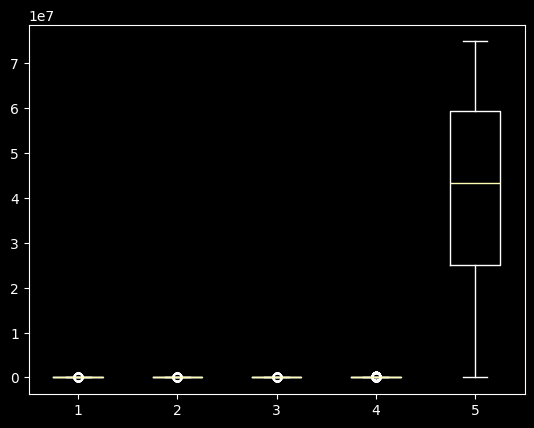

In [28]:
plt.boxplot(x)
plt.show()

In [29]:
print(data['absolute_magnitude'].head())
print(data['absolute_magnitude'].dtype)

162117 (1998 SD15)    19.14
349507 (2008 QY)      18.50
455415 (2003 GA)      21.45
(2002 PB)             20.63
(2011 DW)             22.70
Name: absolute_magnitude, dtype: float64
float64


In [30]:
Q1=x['absolute_magnitude'].quantile(0.25)
Q3=x['absolute_magnitude'].quantile(0.75)
IQR=Q3-Q1

outliers=x[(x['absolute_magnitude']<(Q1-1.5*IQR))|(x['absolute_magnitude']>(Q3+1.5*IQR))]
print("Outliers:")
print(outliers)

Outliers:
                           absolute_magnitude  estimated_diameter_min  \
887 Alinda (A918 AA)                    13.88                4.451998   
(2019 UN13)                             32.00                0.001058   
(2019 UN13)                             32.00                0.001058   
2212 Hephaistos (1978 SB)               13.51                5.279040   
1036 Ganymed (A924 UB)                   9.25               37.545248   
...                                       ...                     ...   
(2020 CW)                               32.56                0.000818   
(2011 CQ1)                              32.10                0.001011   
(2023 RS)                               32.32                0.000913   
(2019 VB5)                              31.70                0.001215   
(2024 HA)                               31.77                0.001176   

                           estimated_diameter_max  relative_velocity  \
887 Alinda (A918 AA)                     

In [31]:
x=x.iloc[:,:].values
x

array([[1.91400000e+01, 3.94961694e-01, 8.83161196e-01, 7.17454010e+04,
        5.81436233e+07],
       [1.85000000e+01, 5.30340723e-01, 1.18587791e+00, 1.09949757e+05,
        5.58010478e+07],
       [2.14500000e+01, 1.36318556e-01, 3.04817558e-01, 2.48655068e+04,
        6.72068877e+07],
       ...,
       [2.19190000e+01, 1.09838597e-01, 2.45606569e-01, 1.18320410e+04,
        5.34607845e+07],
       [2.38870000e+01, 4.43766973e-02, 9.92293117e-02, 5.61983827e+04,
        5.18474239e+06],
       [2.29510000e+01, 6.82896641e-02, 1.52700331e-01, 4.20603578e+04,
        7.12668246e+06]], shape=(338199, 5))

In [32]:
y=is_hazardous.iloc[:,:].values
y

array([[0],
       [1],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(338199, 1))

C:\Users\ANKITA ANAND\AppData\Local\Temp\ipykernel_7004\116496386.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=data['is_hazardous'],kde=True,palette='hot')


<Axes: xlabel='is_hazardous', ylabel='Count'>

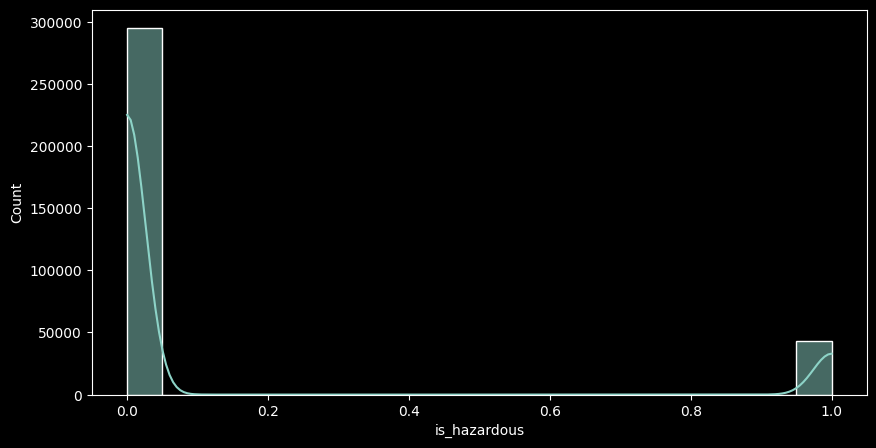

In [33]:
plt.figure(figsize=(10,5))
sns.histplot(data=data['is_hazardous'],kde=True,palette='hot')

In [34]:
df=data['is_hazardous'].values.sum()
print("Dangerous Object =",df,"\n","but Objects that are not dangerous =",338199-df)

Dangerous Object = 43162 
 but Objects that are not dangerous = 295037


In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)

In [36]:
scaler_mm=MinMaxScaler()
X_train_mm=scaler_mm.fit_transform(x_train)
X_test_mm=scaler_mm.fit_transform(x_test)

In [37]:
x_train

array([[2.42000000e+01, 3.84197891e-02, 8.59092601e-02, 4.46451749e+04,
        2.56894851e+07],
       [2.25900000e+01, 8.06408277e-02, 1.80318372e-01, 6.68920967e+04,
        4.81054243e+07],
       [1.99900000e+01, 2.67026877e-01, 5.97090249e-01, 2.47976489e+04,
        2.98984493e+07],
       ...,
       [2.24500000e+01, 8.60111940e-02, 1.92326877e-01, 4.10482768e+04,
        5.13069008e+07],
       [1.71400000e+01, 9.92098919e-01, 2.21840062e+00, 4.28768091e+04,
        5.21529035e+07],
       [2.61300000e+01, 1.57962856e-02, 3.53215683e-02, 3.40373549e+04,
        3.81749990e+07]], shape=(236739, 5))

In [38]:
X_train_mm


array([[6.14467735e-01, 1.00969229e-03, 1.00969229e-03, 1.52418444e-01,
        3.43389291e-01],
       [5.48294287e-01, 2.13424508e-03, 2.13424508e-03, 2.28716862e-01,
        6.43100055e-01],
       [4.41430333e-01, 7.09861733e-03, 7.09861733e-03, 8.43490341e-02,
        3.99664956e-01],
       ...,
       [5.42540074e-01, 2.27728421e-03, 2.27728421e-03, 1.40082462e-01,
        6.85905174e-01],
       [3.24290999e-01, 2.64108327e-02, 2.64108327e-02, 1.46353627e-01,
        6.97216595e-01],
       [6.93793670e-01, 4.07117724e-04, 4.07117724e-04, 1.16037686e-01,
        5.10325991e-01]], shape=(236739, 5))

In [39]:
InputsData_for_Testing=pd.DataFrame(X_test_mm,columns=['absolute_magnitude','estimated_diameter_min','estimated_diameter_max','relative_velocity','miss_distance'])
InputsData_for_Testing

,absolute_magnitude,estimated_diameter_min,estimated_diameter_max,relative_velocity,miss_distance
0,0.750103,0.000210,0.000210,0.113530,0.430642
1,0.659679,0.000603,0.000603,0.081977,0.478136
2,0.666256,0.000559,0.000559,0.085109,0.160261
3,0.453350,0.006209,0.006209,0.102453,0.636707
4,0.371147,0.015618,0.015618,0.285079,0.666496
...,...,...,...,...,...
101455,0.803535,0.000109,0.000109,0.055503,0.856474
101456,0.609947,0.001063,0.001063,0.100722,0.067542
101457,0.667900,0.000549,0.000549,0.188349,0.456800
101458,0.721332,0.000295,0.000295,0.290189,0.821909


In [40]:
'''y_train_flat=np.ravel(y_train)
print('Original dataset shape %s' %Counter(y_train_flat))
#SMOTEENN
smoteenn=SMOTEENN(random_state=42)
X_smoteenn_mm,y_smoteenn_mm=smoteenn.fit_resample(X_train_mm,y_train_flat)
y_smoteenn_mm_flat=np.ravely(y_smoteenn_mm)
print('Resampled dataset shape %s' %Counter(y_smoteenn_mm_flat))'''


"y_train_flat=np.ravel(y_train)\nprint('Original dataset shape %s' %Counter(y_train_flat))\n#SMOTEENN\nsmoteenn=SMOTEENN(random_state=42)\nX_smoteenn_mm,y_smoteenn_mm=smoteenn.fit_resample(X_train_mm,y_train_flat)\ny_smoteenn_mm_flat=np.ravely(y_smoteenn_mm)\nprint('Resampled dataset shape %s' %Counter(y_smoteenn_mm_flat))"

In [41]:
import time 
def get_metrics_results(y_true,y_pred,verbose=False):
    results=[]
    start=time.time()
    for metric_func in [accuracy_score,roc_auc_score,precision_score,recall_score,f1_score]:
        current_res=metric_func(y_true,y_pred)
        results.append(current_res)
        if verbose:print(f"{'metric_func.__name__'}:{current_res}")
        start=time.time()
    return  results
    end=time.time() 
    print('execution time is:')
    print(end-start)
def plot_confusion_matrix(Model_Prediction,title):
    cm=confusion_matrix(y_test,Model_Prediction)
    class_names=['hazardous','non hazardous']
    plt.title(title)
    df_cm=pd.DataFrame(cm,index=[i for i in class_names],columns=[i for i in class_names])
    sns.heatmap(df_cm,annot=True)
    cmap=plt.cm.Blues
    plt.imshow(cm,interpolation='nearest',cmap=cmap)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

LR = LogisticRegression(random_state=0)

parameters = [
    {'penalty': ['l2'], 'C': [0.001, 0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'sag', 'newton-cg'], 'max_iter': [100, 200, 300]},
    {'penalty': ['l1'], 'C': [0.001, 0.01, 0.1, 1, 10], 'solver': ['liblinear', 'saga'], 'max_iter': [100, 200, 300]},
    {'penalty': ['elasticnet'], 'C': [0.001, 0.01, 0.1, 1], 'solver': ['saga'], 'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0], 'max_iter': [100, 200]}
]


lr_clf = RandomizedSearchCV(LR, parameters, scoring='f1', n_iter=30, random_state=0)


lr_clf.fit(X_train_mm, y_train.ravel())

lr_best = lr_clf.best_params_
print(lr_best)


y_pred1 = lr_clf.predict(X_test_mm)



{'solver': 'saga', 'penalty': 'l1', 'max_iter': 300, 'C': 10}


In [43]:
y_pred1

array([0, 0, 0, ..., 0, 0, 0], shape=(101460,))

In [44]:
get_metrics_results(y_test,y_pred1,verbose=True)

metric_func.__name__:0.8714468756160063
metric_func.__name__:0.5333536409328857
metric_func.__name__:0.48971783835485416
metric_func.__name__:0.07876923076923077
metric_func.__name__:0.1357100258432178


[0.8714468756160063,
 np.float64(0.5333536409328857),
 0.48971783835485416,
 0.07876923076923077,
 0.1357100258432178]

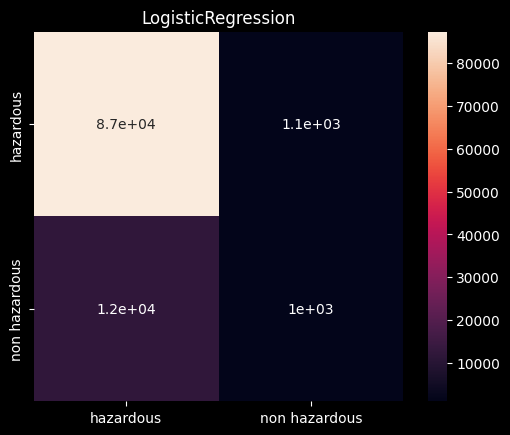

In [45]:
plot_confusion_matrix(y_pred1,"LogisticRegression")

([<matplotlib.patches.Wedge at 0x226aef5a410>,
 [Text(-0.4368623542004964, -1.0095302291077768, 'correct Result'),
  Text(0.4368629880167596, 1.009529954830994, 'Wrong Result')],
 [Text(-0.23828855683663439, -0.5506528522406055, '87%'),
  Text(0.23828890255459612, 0.5506527026350876, '13%')])

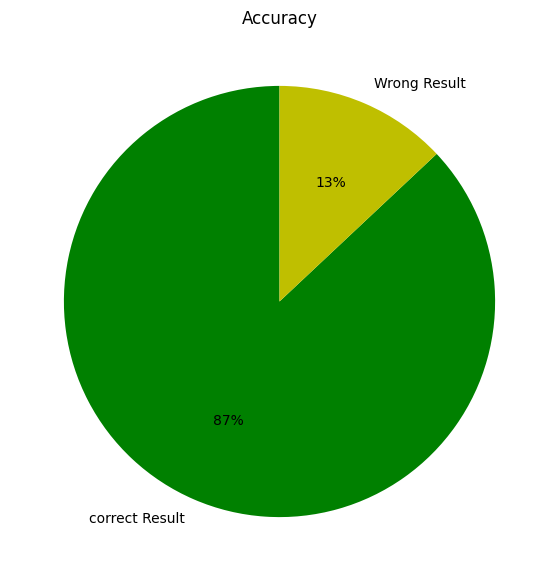

In [46]:
acc1=np.round(accuracy_score(y_test,y_pred1)*100)
plt.style.use('default')
plt.figure(figsize=(12,7))
data=[acc1,100-acc1]
names=['correct Result','Wrong Result']
plt.title('Accuracy',color='black')
plt.pie(data,labels=names,labeldistance=1.1,startangle=90,colors=['g','y'],autopct='%1.0f%%',)

In [47]:
knn=KNeighborsClassifier()
parameters={'n_neighbors':[40,45,50],'weights':['uniform','distance'],'metric':['minkowski','euclidean','manhattan']}
knn_clf=RandomizedSearchCV(knn,parameters,scoring='f1',n_iter=100)
knn_clf.fit(X_train_mm,y_train)
knn_best=knn_clf.best_params_
print(knn_clf.best_params_)


c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=100. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the s

{'weights': 'distance', 'n_neighbors': 40, 'metric': 'manhattan'}


In [48]:
y_pred4=knn_clf.predict(X_test_mm)
y_pred4

array([0, 0, 0, ..., 0, 0, 0], shape=(101460,))

In [49]:
get_metrics_results(y_test,y_pred4,verbose=True)


metric_func.__name__:0.8846737630593338
metric_func.__name__:0.5988145359049722
metric_func.__name__:0.651858779518354
metric_func.__name__:0.21446153846153845
metric_func.__name__:0.32274121664640854


[0.8846737630593338,
 np.float64(0.5988145359049722),
 0.651858779518354,
 0.21446153846153845,
 0.32274121664640854]

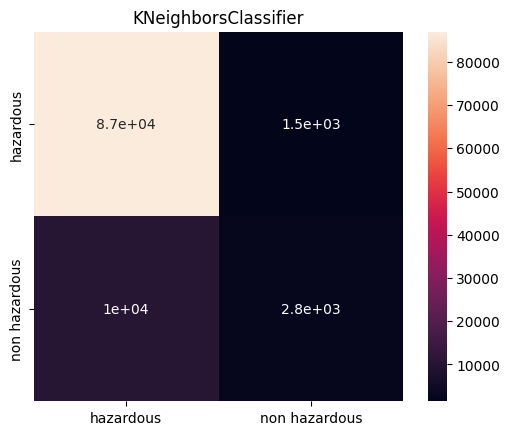

In [50]:
plot_confusion_matrix(y_pred4,"KNeighborsClassifier")

In [51]:
df_comp=pd.DataFrame({'Actual':y_test.ravel(),'Predict':y_pred4.ravel()})
df_comp

,Actual,Predict
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
...,...,...
101455,0,0
101456,0,0
101457,0,0
101458,0,0


<Axes: title={'center': 'Actual & Predict'}>

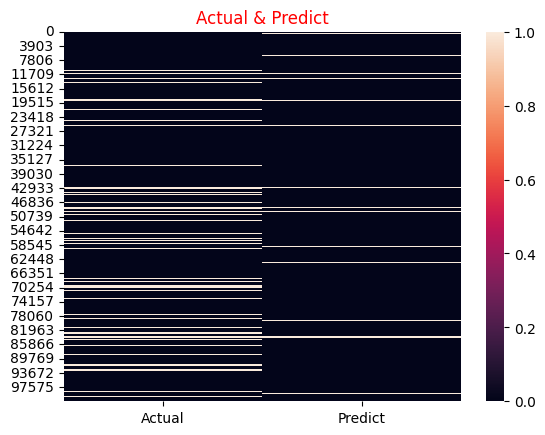

In [52]:
plt.title('Actual & Predict',color='r')
sns.heatmap(df_comp)


([<matplotlib.patches.Wedge at 0x226b6978310>,
 [Text(-0.4049366651053209, -1.0227542702200667, 'Correct Result'),
  Text(0.404936331849658, 1.0227544021651258, 'Wrong Result')],
 [Text(-0.2208745446029023, -0.5578659655745818, '88%'),
  Text(0.22087436282708614, 0.5578660375446141, '12%')])

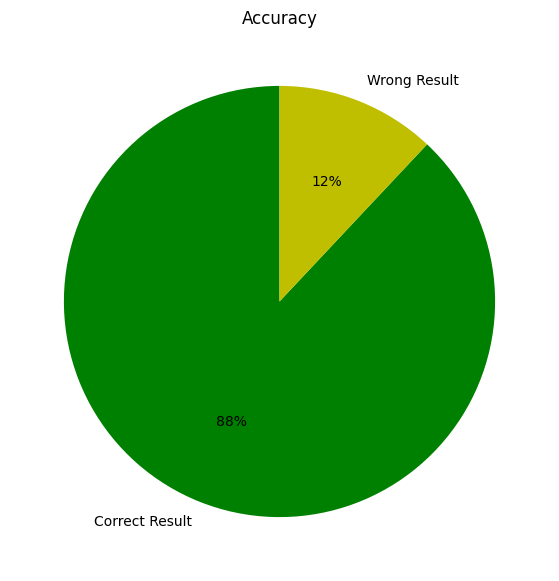

In [53]:
acc=np.round(accuracy_score(y_test,y_pred4)*100)
plt.figure(figsize=(12,7))
data=[acc,100-acc]
names=['Correct Result','Wrong Result']
plt.title('Accuracy',color='black')
plt.pie(data,labels=names,labeldistance=1.1,startangle=90,colors=['g','y'],autopct='%1.0f%%',)

In [54]:
gb=GradientBoostingClassifier()
gb.fit(X_train_mm,y_train)
y_pred8=gb.predict(X_test_mm)
y_pred8

c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, ..., 0, 0, 0], shape=(101460,))

In [55]:
get_metrics_results(y_test,y_pred8,verbose=True)


metric_func.__name__:0.885846639069584
metric_func.__name__:0.5797687872832571
metric_func.__name__:0.739851150202977
metric_func.__name__:0.16823076923076924
metric_func.__name__:0.274128854349461


[0.885846639069584,
 np.float64(0.5797687872832571),
 0.739851150202977,
 0.16823076923076924,
 0.274128854349461]

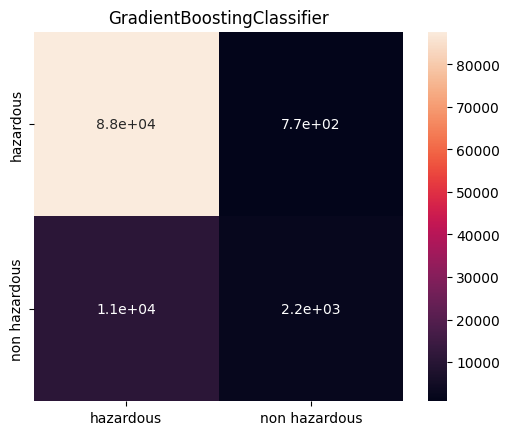

In [56]:
plot_confusion_matrix(y_pred8,"GradientBoostingClassifier")


In [57]:
df_comp=pd.DataFrame({'Actual':y_test.ravel(),'predict':y_pred8.ravel()})
df_comp


,Actual,predict
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
...,...,...
101455,0,0
101456,0,0
101457,0,0
101458,0,0


<Axes: title={'center': 'Actual & predict'}>

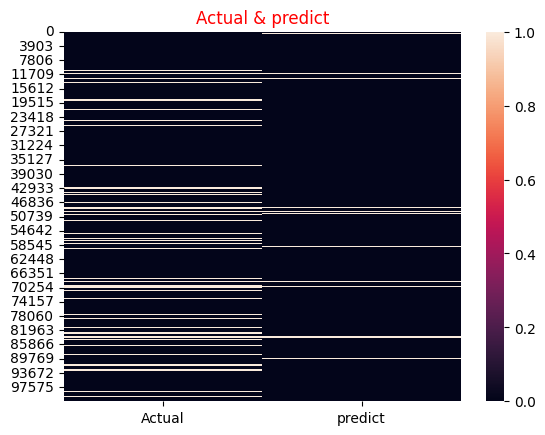

In [58]:
plt.title('Actual & predict',color='r')
sns.heatmap(df_comp)

([<matplotlib.patches.Wedge at 0x226b6f01660>,
 [Text(-0.37261184559641247, -1.0349687978491118, 'correct result'),
  Text(0.37261200187234894, 1.0349687415862765, 'wrong result')],
 [Text(-0.20324282487077042, -0.5645284351904245, '89%'),
  Text(0.2032429101121903, 0.5645284045016052, '11%')])

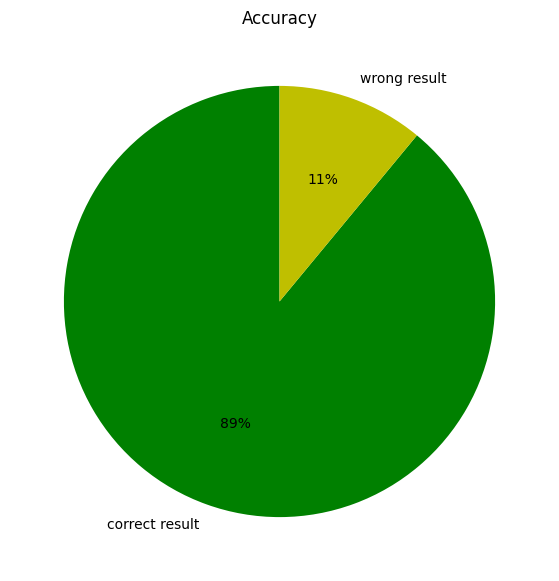

In [59]:
acc=np.round(accuracy_score(y_test,y_pred8)*100)
plt.figure(figsize=(12,7))
data=[acc,100-acc]
names=['correct result','wrong result']
plt.title('Accuracy',color='black')
plt.pie(data,labels=names,labeldistance=1.1,startangle=90,colors=['g','y'],autopct='%1.0f%%',)

In [60]:
import tensorflow as tf
model=tf.keras.models.Sequential([tf.keras.layers.Dense(64,activation='relu',input_shape=(X_train_mm.shape[1],)),tf.keras.layers.Dense(32,activation='relu'),tf.keras.layers.Dense(16,activation='relu'),tf.keras.layers.Dense(8,activation='relu'),tf.keras.layers.Dense(1,activation='sigmoid')])

c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step - accuracy: 0.8774 - loss: 0.2890 - val_accuracy: 0.8818 - val_loss: 0.2498
Epoch 2/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8831 - loss: 0.2482 - val_accuracy: 0.8822 - val_loss: 0.2436
Epoch 3/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8847 - loss: 0.2444 - val_accuracy: 0.8835 - val_loss: 0.2416
Epoch 4/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8837 - loss: 0.2450 - val_accuracy: 0.8828 - val_loss: 0.2429
Epoch 5/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8841 - loss: 0.2433 - val_accuracy: 0.8833 - val_loss: 0.2416
Epoch 6/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8841 - loss: 0.2436 - val_accuracy: 0.8839 - val_loss: 0.2439
Epoch 7/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8833 - loss: 0.2448 - val_accuracy: 0.8844 - val_loss: 0.2413
Epoch 8/20
7399/7399 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.8844 - loss: 0

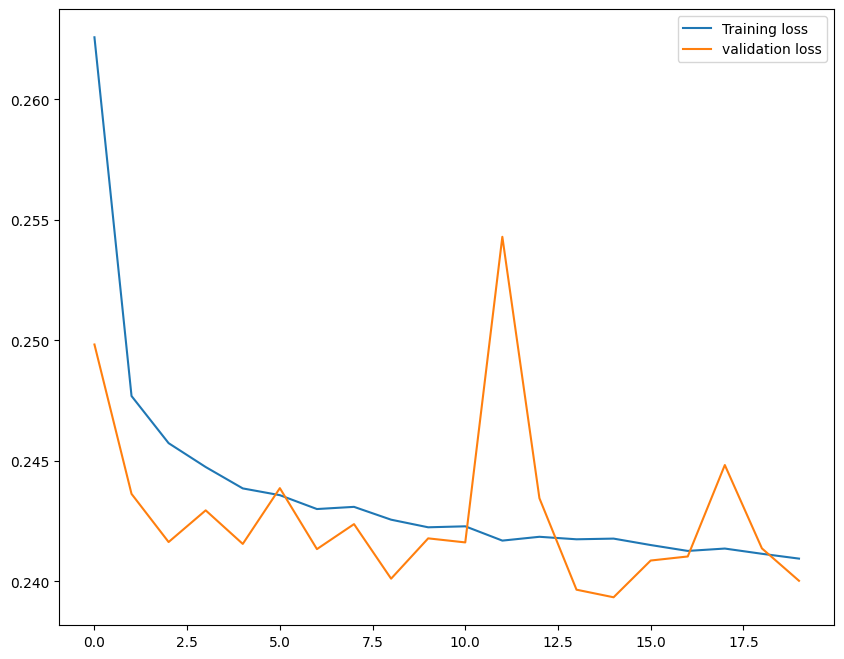

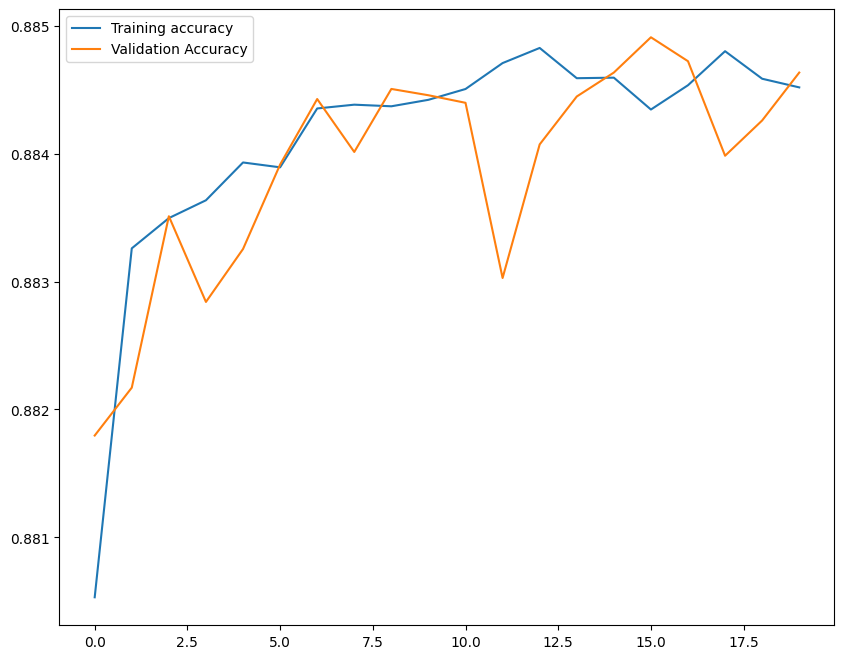

In [61]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop=EarlyStopping(patience=15)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
history=model.fit(X_train_mm,y_train,epochs=20,batch_size=32,verbose=1,validation_data=(X_test_mm,y_test),callbacks=[early_stop])
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(history.history['loss'],label='Training loss')
ax.plot(history.history['val_loss'],label='validation loss')
ax.legend()
plt.show()

fig,ax=plt.subplots(figsize=(10,8))
ax.plot(history.history['accuracy'],label='Training accuracy')
ax.plot(history.history['val_accuracy'],label='Validation Accuracy')
ax.legend()
plt.show()

In [62]:
def evaluate_model(model,X_train,y_train,X_test,y_test,batch_size=10000):
    model.fit(X_train,y_train)
    train_acc=model.score(X_train,y_train)
    test_acc=model.score(X_test,y_test)
    y_pred=[]
    for i in range(0,len(X_test),batch_size):
        batch=X_test[i:i+batch_size]
        y_pred_batch=model.predict(batch)
        y_pred.extend(y_pred_batch)

    return train_acc,test_acc,y_pred 
X_train_sample,_,y_train_sample,_=train_test_split(X_train_mm,y_train,test_size=0.9,random_state=42)
X_test_sample,_,y_test_sample,_=train_test_split(X_test_mm,y_test,test_size=0.9,random_state=42)

models=[
    LogisticRegression(),
    RandomForestClassifier(),
    KNeighborsClassifier(),
    XGBClassifier(),
    CatBoostClassifier(),
    AdaBoostClassifier(),
    GradientBoostingClassifier()
]

model_names=["Logistic Regression","Random Forest","KNeighbors Classifier","XGBoost","CatBoost","AdaBoost","Gradient Boosting"]

train_results=[]
test_results=[]

for model in models:
    train_acc,test_acc,y_pred=evaluate_model(model,X_train_sample,y_train_sample,X_test_sample,y_test_sample)
    train_results.append(train_acc)
    test_results.append(test_acc)

print("Training Accuracies:",train_results)
print("Testing Accuracies:",test_results)



c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Learning rate set to 0.039787
0:	learn: 0.6040899	total: 145ms	remaining: 2m 24s
1:	learn: 0.5477483	total: 153ms	remaining: 1m 16s
2:	learn: 0.4966990	total: 160ms	remaining: 53.3s
3:	learn: 0.4553771	total: 167ms	remaining: 41.7s
4:	learn: 0.4216301	total: 174ms	remaining: 34.7s
5:	learn: 0.3889587	total: 181ms	remaining: 30s
6:	learn: 0.3630456	total: 188ms	remaining: 26.7s
7:	learn: 0.3438873	total: 196ms	remaining: 24.3s
8:	learn: 0.3279515	total: 203ms	remaining: 22.4s
9:	learn: 0.3162186	total: 212ms	remaining: 21s
10:	learn: 0.3062022	total: 219ms	remaining: 19.7s
11:	learn: 0.2972732	total: 228ms	remaining: 18.7s
12:	learn: 0.2895990	total: 235ms	remaining: 17.8s
13:	learn: 0.2837849	total: 243ms	remaining: 17.1s
14:	learn: 0.2784525	total: 250ms	remaining: 16.4s
15:	learn: 0.2735461	total: 257ms	remaining: 15.8s
16:	learn: 0.2697936	total: 264ms	remaining: 15.3s
17:	learn: 0.2671040	total: 272ms	remaining: 14.8s
18:	learn: 0.2645463	total: 279ms	remaining: 14.4s
19:	learn: 0.

c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training Accuracies: [0.8636843661555358, 1.0, 0.9068559117982512, 0.9249778228361425, np.float64(0.8337500373765908), 0.8825243948802434, 0.8867486165673975]
Testing Accuracies: [0.8640843682239306, 0.8849793021880544, 0.8668440764833432, 0.8823181549379066, np.float64(0.8387531397014586), 0.8837965700768776, 0.8860634732899665]


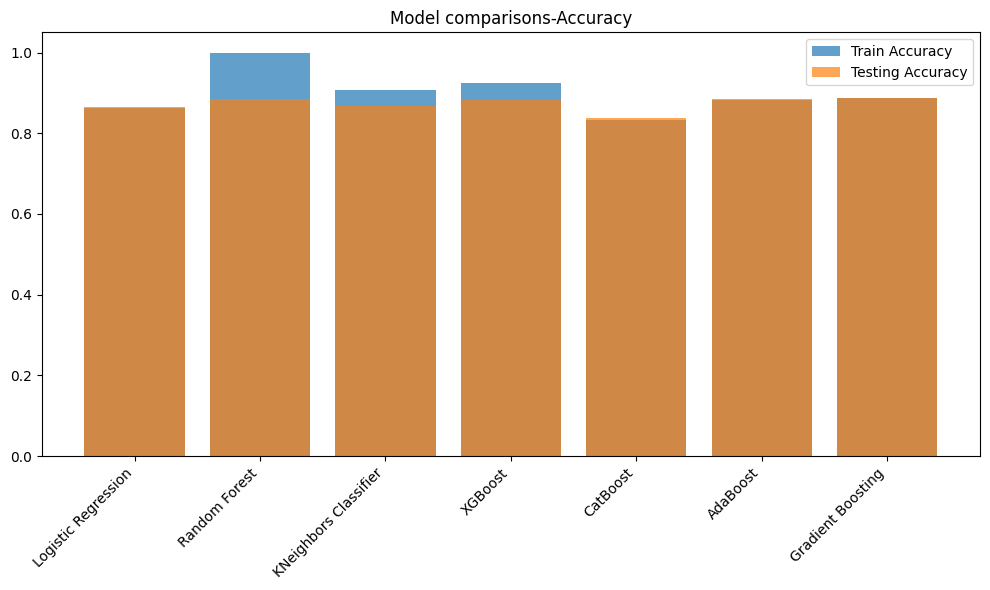

In [63]:
plt.figure(figsize=(10,6))
plt.bar(model_names,train_results,alpha=0.7,label="Train Accuracy")
plt.bar(model_names,test_results,alpha=0.7,label="Testing Accuracy")
plt.ylabel=("Accuracy")
plt.xticks(rotation=45,ha="right")
plt.legend()
plt.title("Model comparisons-Accuracy")
plt.tight_layout()
plt.show()

In [76]:
model = RandomForestClassifier()
model.fit(x_train, y_train) 


with open('NEO-AI.pkl', 'wb') as f:
    pickle.dump(model, f)


with open('NEO-AI.pkl', 'rb') as f:
    pickled_model = pickle.load(f)


random_row = InputsData_for_Testing.sample(n=1)
prediction = pickled_model.predict(random_row)
print(prediction)

c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


[0]


c:\Users\ANKITA ANAND\Anaconda2\env\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
converter=pyttsx3.init()
converter.setProperty('rate',120)
converter.setProperty('volume',1)
if prediction==1:
    converter.say("Hello Be Careful.this Object must be dealt with urgently,this object has become a threat to our planet")
elif prediction==0:
    converter.say("Hello this onject is simple and,according to my analysis,does not pose a threat to the planet..")
converter.say("For your safety,I am just a machine learning model.but I am here to help you.You can report it to the nearset space science center for more peace of mind.")
converter.runAndWait()

RuntimeError: run loop already started